In [2]:
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
import statsmodels.tsa.api as tsa
import statsmodels.graphics.api as smg

In [3]:
np.random.seed(42)
x = np.random.rand(100, 1)
y = 2 + 3 * x + np.random.rand(100, 1)

x = sm.add_constant(x)
model = sm.OLS(y, x)
results = model.fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.901
Model:                            OLS   Adj. R-squared:                  0.900
Method:                 Least Squares   F-statistic:                     889.4
Date:                Tue, 19 May 2026   Prob (F-statistic):           5.86e-51
Time:                        14:59:23   Log-Likelihood:                -18.613
No. Observations:                 100   AIC:                             41.23
Df Residuals:                      98   BIC:                             46.44
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.5136      0.055     45.482      0.0

In [4]:
import pandas as pd

np.random.seed(42)
data = {'A': np.random.randint(0, 2, 100),
        'B': np.random.randint(0, 2, 100),
        'C': np.random.randint(0, 2, 100)}
df = pd.DataFrame(data)

model = smf.ols('A ~ B + C', data=df)
results = model.fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                      A   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                 -0.020
Method:                 Least Squares   F-statistic:                   0.03724
Date:                Tue, 19 May 2026   Prob (F-statistic):              0.963
Time:                        14:59:24   Log-Likelihood:                -71.816
No. Observations:                 100   AIC:                             149.6
Df Residuals:                      97   BIC:                             157.4
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.5414      0.085      6.351      0.0

In [5]:
np.random.seed(42)
data = np.random.rand(100, 1)

model = tsa.ARIMA(data, order=(1, 1, 1))
results = model.fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  100
Model:                 ARIMA(1, 1, 1)   Log Likelihood                 -22.598
Date:                Tue, 19 May 2026   AIC                             51.195
Time:                        14:59:24   BIC                             58.981
Sample:                             0   HQIC                            54.345
                                - 100                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0563      0.100      0.562      0.574      -0.140       0.253
ma.L1         -1.0000     56.992     -0.018      0.986    -112.702     110.702
sigma2         0.0883      5.034      0.018      0.986      -9.778       9.954
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                 6.35
Prob(Q):                              0.98   Prob(JB):                         0.04
Heteroskedasticity (H):               1.03   Skew:                             0.13
Prob(H) (two-sided):                  0.94   Kurtosis:                         1.79
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [6]:
np.random.seed(42)
X = np.random.rand(100, 1)
y = 2 + 3 * X + np.random.randn(100, 1)

X = sm.add_constant(X)
model = sm.OLS(y, X)
results = model.fit()

t_test = results.t_test([0, 1])
print(t_test)

                             Test for Constraints                             
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
c0             2.5402      0.306      8.288      0.000       1.932       3.148


In [7]:
from scipy.stats import chisquare

counts = [150, 80, 100, 70]

n_categories = len(counts)
total = sum(counts)
expected = [total/n_categories] * n_categories

chi2_stat, p_value = chisquare(
  f_obs=counts,        # Observed frequencies
  f_exp=expected,      # Expected frequencies
  ddof=0               # Degrees of freedom adjustment
)

print(f"Chi-square statistic: {chi2_stat}")
print(f"P-value: {p_value}")

alpha = 0.05
if p_value < alpha:
  print("Reject the null hypothesis: The proportions are significantly different.")
else:
  print("Fail to reject the null hypothesis: The proportions are not significantly different.")

Chi-square statistic: 38.0
P-value: 2.8264748814532456e-08
Reject the null hypothesis: The proportions are significantly different.


<Figure size 1000x800 with 0 Axes>

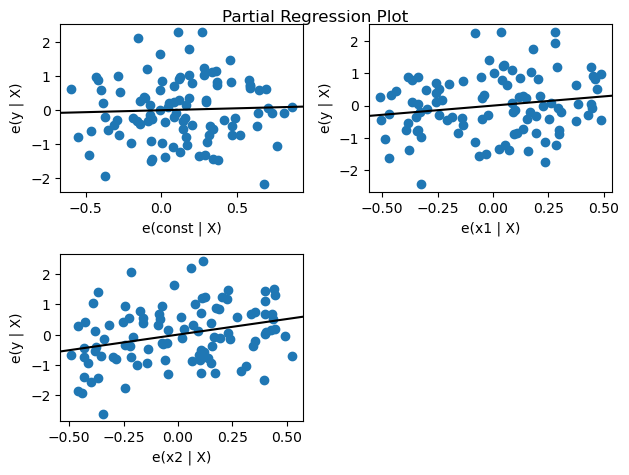

<Figure size 1000x800 with 0 Axes>

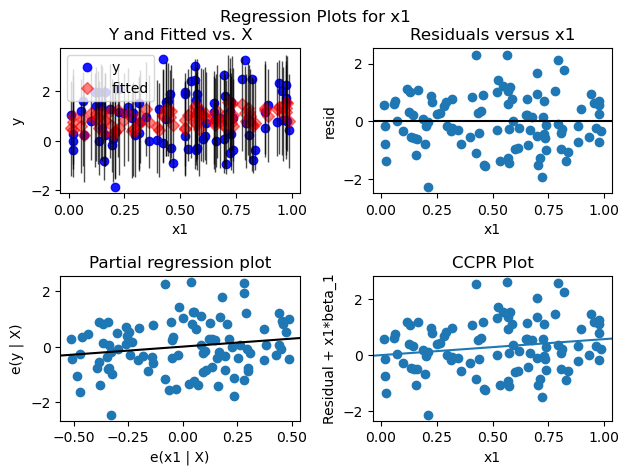

In [8]:
from matplotlib import pyplot as plt
import numpy as np

np.random.seed(0)
X = np.random.rand(100, 2)
X = sm.add_constant(X)
y = X[:, 1] + X[:, 2] + np.random.randn(100)  # Dependent variable with some noise

model = sm.OLS(y, X)
results = model.fit()

fig = plt.figure(figsize=(10, 8))
fig = sm.graphics.plot_partregress_grid(results)
plt.show()

# Alternatively, generate a residual plot for the first independent variable
fig = plt.figure(figsize=(10, 8))
fig = sm.graphics.plot_regress_exog(results, 1)
plt.show()

In [9]:
X = np.random.rand(5, 1)  # Independent variable (100 samples)
y = 3 * X + np.random.randn(5, 1)  # Dependent variable with noise

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

residuals = model.resid
print("Model Residuals:\n", residuals)

Model Residuals:
 [ 0.32374968 -1.06134961  0.03295618 -0.32718572  1.03182948]


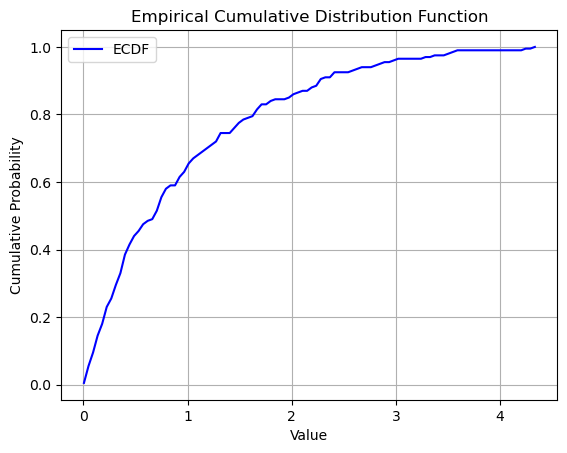


Cumulative probabilities:
P(X ≤ 0.5) = 0.450
P(X ≤ 1.0) = 0.635
P(X ≤ 1.5) = 0.780


In [10]:
from statsmodels.distributions.empirical_distribution import ECDF

np.random.seed(42)
data = np.random.exponential(size=200)

ecdf = ECDF(data)
x = np.linspace(min(data), max(data), 100)
y = ecdf(x)

plt.plot(x, y, 'b-', label='ECDF')
plt.xlabel('Value')
plt.ylabel('Cumulative Probability')
plt.title('Empirical Cumulative Distribution Function')
plt.grid(True)
plt.legend()
plt.show()

points = [0.5, 1.0, 1.5]
probabilities = ecdf(points)

print("\nCumulative probabilities:")
for point, prob in zip(points, probabilities):
  print(f"P(X ≤ {point:.1f}) = {prob:.3f}")

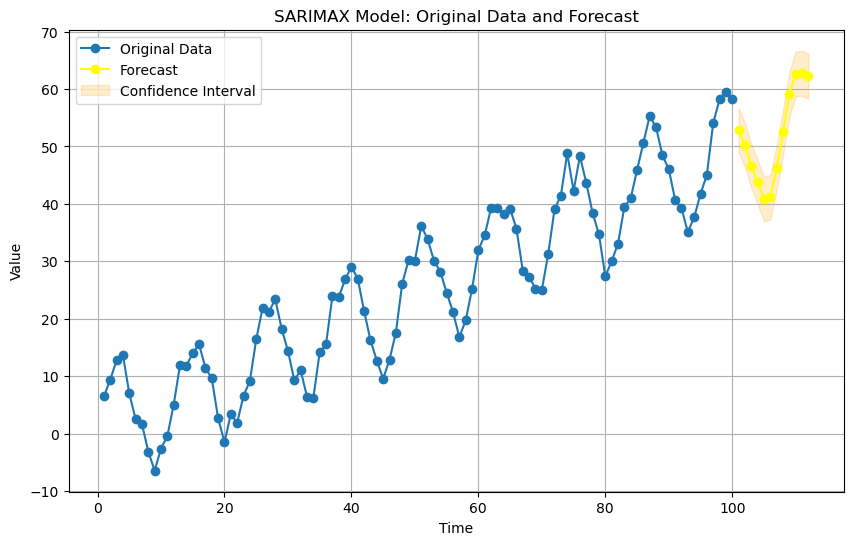

In [11]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

np.random.seed(42)
n = 100
time = np.arange(1, n + 1)
seasonality = 10 * np.sin(2 * np.pi * time / 12)
trend = 0.5 * time
noise = np.random.normal(scale=2, size=n)
data = trend + seasonality + noise

exog = 5 * np.sin(2 * np.pi * time / 6) + np.random.normal(scale=1, size=n)

df = pd.DataFrame({'Time': time, 'Value': data, 'Exog': exog})

model = SARIMAX(
    df['Value'],
    exog=df['Exog'],
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12)
)
result = model.fit(disp=False)

forecast_exog = np.array([5] * 12).reshape(-1, 1)

forecast = result.get_forecast(steps=12, exog=forecast_exog)
forecast_values = forecast.predicted_mean
forecast_ci = forecast.conf_int()

plt.figure(figsize=(10, 6))
plt.plot(df['Time'], df['Value'], label="Original Data", marker='o')
plt.plot(
    range(n + 1, n + 13),
    forecast_values,
    label="Forecast",
    color='yellow',
    marker='o'
)
plt.fill_between(
    range(n + 1, n + 13),
    forecast_ci.iloc[:, 0],
    forecast_ci.iloc[:, 1],
    color='orange',
    alpha=0.2,
    label="Confidence Interval"
)
plt.xlabel("Time")
plt.ylabel("Value")
plt.title("SARIMAX Model: Original Data and Forecast")
plt.legend()
plt.grid()
plt.show()